In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer #convert text to numeric features

In [2]:
df= pd.read_csv('jupyter_env/news.csv')

In [3]:
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6335 non-null   int64 
 1   title       6335 non-null   object
 2   text        6335 non-null   object
 3   label       6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB


In [5]:
df.describe()

,Unnamed: 0
count,6335.000000
mean,5280.415627
std,3038.503953
min,2.000000
25%,2674.500000
50%,5271.000000
75%,7901.000000
max,10557.000000


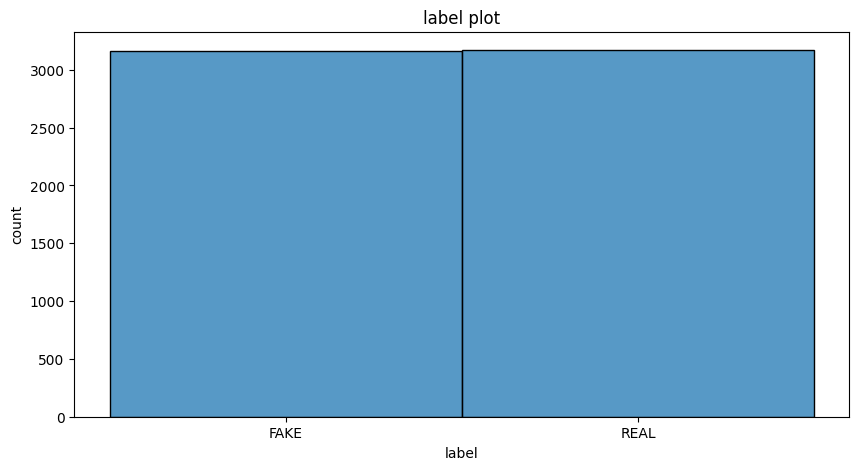

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='label')
plt.title('label plot')
plt.xlabel('label')
plt.ylabel('count')
plt.show()

In [7]:
x= df['title'] + ' ' + df['text'] #combine title and text into one column,  TF-IDF can't handle a DataFrame with 2 columns
y=df['label']

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

Let’s initialize a TfidfVectorizer with stop words from the English language and a maximum document frequency of 0.7 (terms with a higher document frequency will be discarded). Stop words are the most common words in a language that are to be filtered out before processing the natural language data. And a TfidfVectorizer turns a collection of raw documents into a matrix of TF-IDF features.

Now, fit and transform the vectorizer on the train set, and transform the vectorizer on the test set.

In [8]:
#Initialize a TfidfVectorizer
tfidf_vectorizer=TfidfVectorizer(stop_words='english', max_df=0.7)

#Fit and transform train set, transform test set
x_train_vec=tfidf_vectorizer.fit_transform(x_train) 
x_test_vec=tfidf_vectorizer.transform(x_test)

In [9]:
# Run these and tell me what you see
print(x_train.shape)
print(x_test.shape)
print(len(y_train))
print(len(y_test))

(5068,)
(1267,)
5068
1267


In [10]:
model= LogisticRegression(max_iter=1000)
model.fit(x_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [11]:
y_pred= model.predict(x_train_vec)
print(y_pred[:10])

['REAL' 'FAKE' 'FAKE' 'FAKE' 'FAKE' 'FAKE' 'REAL' 'FAKE' 'REAL' 'REAL']


In [12]:
results_df= pd.DataFrame({
    'actual': y_train,
    'predicted': y_pred
})
print('actual vs predicted:')
display(results_df.head(10))

actual vs predicted:


,actual,predicted
471,REAL,REAL
4825,FAKE,FAKE
6166,FAKE,FAKE
4886,FAKE,FAKE
2646,FAKE,FAKE
341,FAKE,FAKE
1353,FAKE,REAL
5522,FAKE,FAKE
1969,REAL,REAL
1145,REAL,REAL


In [13]:
y_pred_test= model.predict(x_test_vec)
print(y_pred_test[:10])

['REAL' 'FAKE' 'REAL' 'FAKE' 'REAL' 'REAL' 'REAL' 'REAL' 'FAKE' 'REAL']


In [14]:
test_results_df= pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred_test
})
print('ACTUAL VS PREDICTED RESULTS')
display(test_results_df.head(10))

ACTUAL VS PREDICTED RESULTS


,actual,predicted
1707,REAL,REAL
1926,FAKE,FAKE
2674,REAL,REAL
2597,FAKE,FAKE
4602,REAL,REAL
5179,REAL,REAL
863,REAL,REAL
1162,REAL,REAL
3821,FAKE,FAKE
3388,REAL,REAL


MODEL EVALUATION ACCURACY

In [15]:
y_pred= model.predict(x_train_vec)
train_accuracy= accuracy_score(y_train, y_pred)
print(f'training accuracy: {train_accuracy:.4f}')

training accuracy: 0.9566


In [16]:
y_pred_test= model.predict(x_test_vec)
train_accuracy= accuracy_score(y_test, y_pred_test)
print(f'testing accuracy: {train_accuracy:.4f}')

testing accuracy: 0.9203


In [17]:
print(f'confusion matrix(test set):')
cm= confusion_matrix(y_test, y_pred_test)
print(cm)

confusion matrix(test set):
[[600  33]
 [ 68 566]]


So with this model, we have 600 true positives, 566 true negatives, 68 false positives, and 33 false negatives.

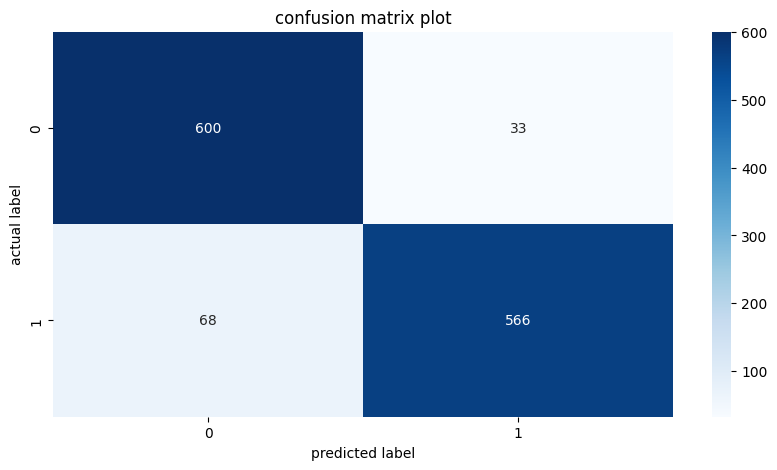

In [18]:
#plot the confusion matrix
plt.figure(figsize=(10,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('confusion matrix plot')
plt.xlabel('predicted label')
plt.ylabel('actual label')
plt.show()

In [20]:
import pickle

# 1. Save the trained Logistic Regression model
with open('fake_news_model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)

# 2. Save the TF-IDF Vectorizer (VERY IMPORTANT)
with open('tfidf_vectorizer.pkl', 'wb') as vectorizer_file:
    pickle.dump(tfidf_vectorizer, vectorizer_file)

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!
